5) For each signaling/metabolic pathway in the database, list the drugs that interact with it. Present the results in the form of a data frame as well as a custom graphical representation. One example of such a visualization is a bipartite graph, where one set of nodes represents signaling pathways and the other represents drugs, with edges indicating interactions. Ensure the visualization is clear, readable, and visually appealing.

In [1]:
import xml.etree.ElementTree as ET
import pandas as pd

# Define the file path and namespace
file_path = 'drugbank_partial.xml'
namespace = {'drugbank': 'http://www.drugbank.ca'}
data = []
pathways = set()

# Parse the XML file and extract relevant information
for event, elem in ET.iterparse(file_path, events=('start', 'end')):
    if elem.tag == f"{{{namespace['drugbank']}}}pathway" and event == 'end':
        id = elem.find('drugbank:smpdb-id', namespace).text
        if id not in pathways:
            pathways.add(id)
            pathway_dict = {}
            pathway_dict['name'] = elem.find('drugbank:name', namespace).text
            drugs = elem.find('drugbank:drugs', namespace)
            pathway_dict['drugs'] = [drug.find('drugbank:drugbank-id', namespace).text for drug in drugs.findall('drugbank:drug', namespace)]
            data.append(pathway_dict)
        elem.clear()

# Create a DataFrame from the extracted data
df = pd.DataFrame(data)
df

,name,drugs
0,Lepirudin Action Pathway,"[DB00001, DB01022, DB01373]"
1,Cetuximab Action Pathway,[DB00002]
2,Bivalirudin Action Pathway,"[DB00006, DB01022, DB01373]"
3,Alteplase Action Pathway,"[DB00009, DB01022, DB01373]"
4,Urokinase Action Pathway,"[DB00013, DB01022, DB01373]"
5,Reteplase Action Pathway,"[DB00015, DB01022, DB01373]"
6,Anistreplase Action Pathway,"[DB00029, DB01022, DB01373]"
7,Tenecteplase Action Pathway,"[DB00031, DB01022, DB01373]"
8,Abciximab Action Pathway,[DB00054]
9,Eptifibatide Action Pathway,[DB00063]


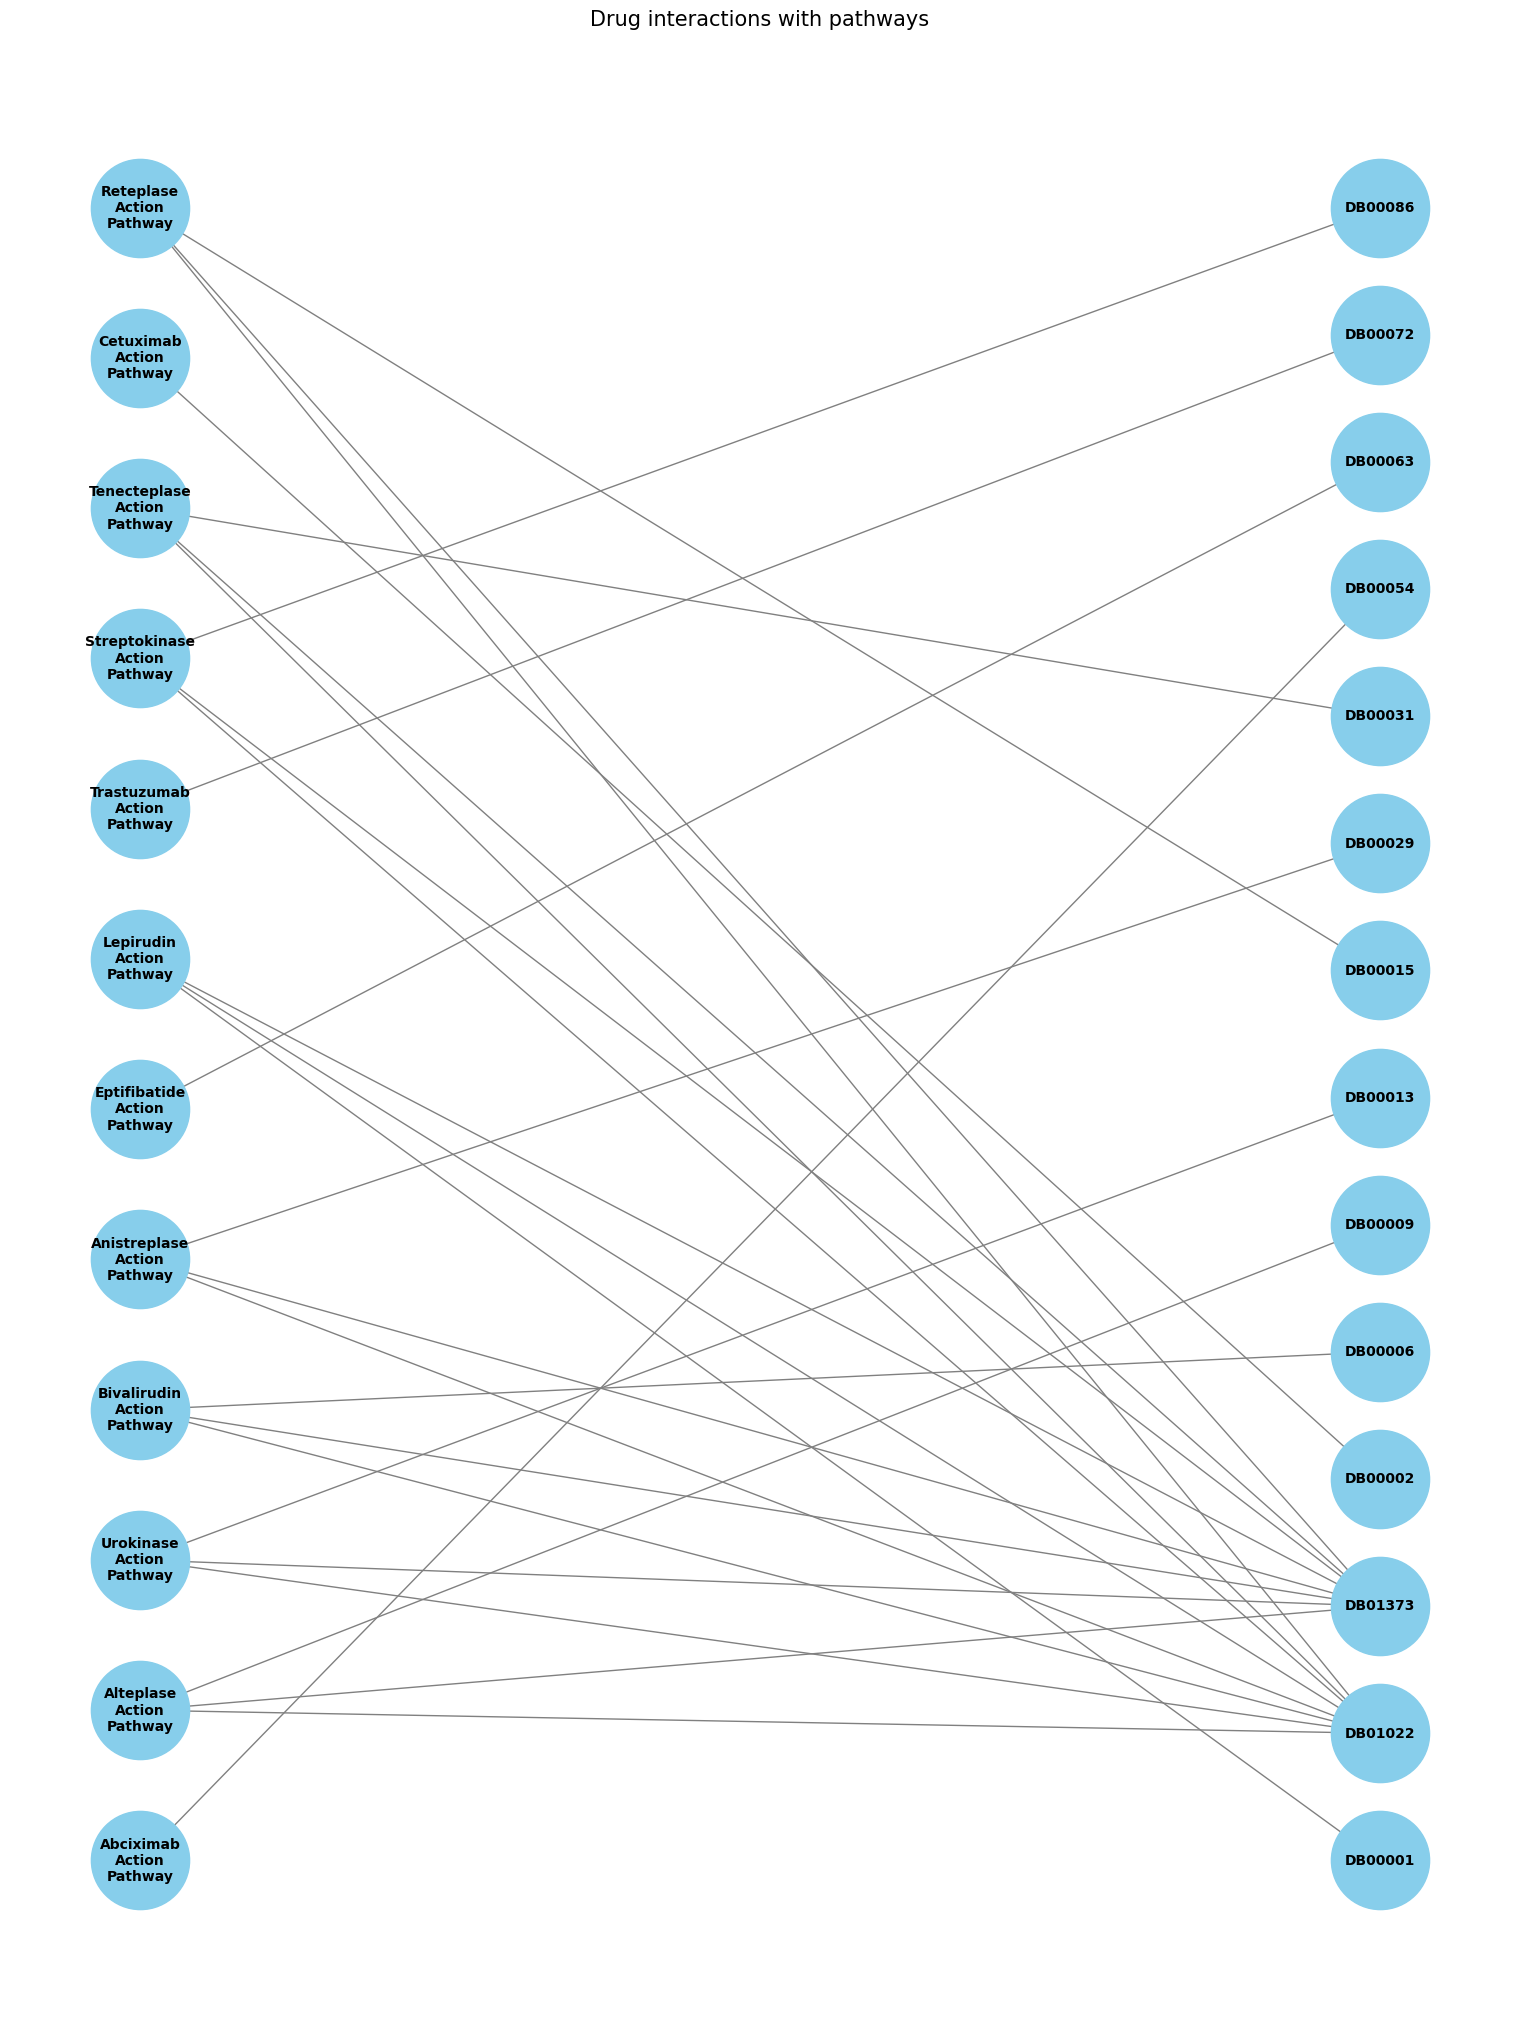

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from textwrap import wrap

# Create a bipartite graph
G = nx.Graph()
pathways = set()
drugs = set()

# Add nodes and edges to the graph
for index, row in df.iterrows():
    pathway_name = row['name']
    pathways.add(pathway_name)
    G.add_node(pathway_name, bipartite=0)
    for drug in row['drugs']:
        drugs.add(drug)
        G.add_node(drug, bipartite=1)
        G.add_edge(pathway_name, drug)

# Draw the graph
pos = nx.bipartite_layout(G, pathways)
plt.figure(figsize=(15, 20))
labels = {node: '\n'.join(wrap(node, 13)) for node in G.nodes()}
nx.draw(G, pos, labels=labels, node_size=5000, node_color='skyblue', font_size=10, font_weight='bold', edge_color='gray')

plt.title('Drug interactions with pathways', fontsize=15)
plt.show()
